# **Análise Exploratória de Dados: Risco de Saúde**

Neste notebook vamos aprender, na prática, como **explorar e entender um conjunto de dados** usando Python.

Vamos usar uma base de dados sobre hábitos de vida (exercício, sono, tabagismo, consumo de álcool e açúcar, etc.) e o risco de saúde de cada pessoa (`risco_saude`: `baixo` ou `alto`).

Este notebook já está preparado para ler o arquivo **`Lifestyle_and_Health_Risk_Prediction_Dataset_PT.csv`**, cujas colunas e valores já estão traduzidos para português:

| Coluna | Significado |
|---|---|
| `idade` | idade da pessoa |
| `peso` | peso (kg) |
| `altura` | altura (cm) |
| `exercicio` | nível de exercício (baixo / medio / alto / nenhum) |
| `sono` | horas de sono |
| `consumo_acucar` | consumo de açúcar (baixo / medio / alto) |
| `fumante` | se fuma (sim / nao) |
| `alcool` | se consome álcool (sim / nao) |
| `casado` | se é casado(a) (sim / nao) |
| `profissao` | profissão |
| `imc` | Índice de Massa Corporal |
| `risco_saude` | risco de saúde (baixo / alto) |

> **Observação para os alunos:** este material foi adaptado de um projeto de Machine Learning. Aqui removemos toda a parte de criação/treinamento de modelo preditivo e mantivemos apenas a etapa de **Análise Exploratória de Dados (EDA)**, que é a base para qualquer projeto de dados: entender o que existe antes de tentar prever algo.


In [19]:
# ============================================================
# IMPORTANDO AS BIBLIOTECAS QUE VAMOS USAR
# ============================================================
# numpy   -> biblioteca para trabalhar com números e vetores/matrizes
# pandas  -> biblioteca para manipular tabelas de dados (DataFrames)
# matplotlib.pyplot -> biblioteca para criar gráficos
# seaborn -> biblioteca construída sobre o matplotlib, com gráficos
#            estatísticos mais bonitos e prontos para usar
# warnings -> usada aqui apenas para "silenciar" avisos e deixar a
#             saída do notebook mais limpa

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Define o tamanho padrão (largura, altura) que os gráficos vão ter
plt.rcParams['figure.figsize'] = (10, 5)

# Define um "estilo visual" pronto para os gráficos do matplotlib
plt.style.use('fivethirtyeight')

# Ignora mensagens de aviso (warnings) que não impedem o código de funcionar
warnings.filterwarnings('ignore')


In [14]:
# ============================================================
# CARREGANDO A BASE DE DADOS (JÁ TRADUZIDA PARA PORTUGUÊS)
# ============================================================
# pd.read_csv() lê um arquivo no formato CSV (valores separados por vírgula)
# e transforma ele em um DataFrame (uma espécie de "tabela" do pandas).
#
# Se o arquivo estiver em outra pasta, ajuste o caminho abaixo.
# Ex.: pd.read_csv('/caminho/para/o/arquivo.csv')

df = pd.read_csv('C:\Pedro Augusto Taroco Santos\CursoPython\py\Analise_Dados\ArquivoExcel\Lifestyle_and_Health_Risk_Prediction_Dataset_PT.csv')


In [15]:
# ============================================================
# OBSERVANDO AS PRIMEIRAS LINHAS DA TABELA
# ============================================================
# .head() mostra, por padrão, as 5 primeiras linhas do DataFrame.
# É sempre um dos primeiros comandos a rodar para "dar uma olhada"
# em como os dados estão organizados (quais colunas existem, que
# tipo de valor cada uma tem, etc.)

df.head()


,idade,peso,altura,exercicio,sono,consumo_acucar,fumante,alcool,casado,profissao,imc,risco_saude
0,56,67,195,baixo,6.1,medio,sim,sim,sim,trabalhador_de_escritorio,17.6,alto
1,69,76,170,alto,6.9,alto,nao,nao,nao,professor,26.3,alto
2,46,106,153,alto,6.6,baixo,sim,nao,nao,artista,45.3,alto
3,32,54,186,medio,8.5,medio,nao,nao,nao,artista,15.6,baixo
4,60,98,195,alto,8.0,baixo,nao,nao,sim,professor,25.8,alto


In [16]:
# ============================================================
# OBSERVANDO AS ÚLTIMAS LINHAS DA TABELA
# ============================================================
# .tail() faz o mesmo que o .head(), mas mostra as últimas linhas.
# É útil para conferir se o arquivo foi carregado até o fim
# corretamente (sem cortes ou linhas quebradas).

df.tail()


,idade,peso,altura,exercicio,sono,consumo_acucar,fumante,alcool,casado,profissao,imc,risco_saude
4995,42,75,187,medio,7.2,baixo,nao,nao,sim,motorista,21.4,baixo
4996,39,86,183,baixo,7.4,baixo,nao,nao,sim,engenheiro,25.7,alto
4997,48,56,194,nenhum,7.2,alto,sim,sim,sim,engenheiro,14.9,alto
4998,34,109,148,medio,9.9,medio,nao,nao,sim,medico,49.8,baixo
4999,72,47,149,alto,6.3,medio,nao,nao,sim,motorista,21.2,baixo


In [17]:
# ============================================================
# OBSERVANDO O TAMANHO DA TABELA (LINHAS x COLUNAS)
# ============================================================
# .shape retorna uma tupla (número_de_linhas, número_de_colunas).
# Isso ajuda a entender o "tamanho" da base de dados: quantas
# pessoas (linhas) e quantas características/variáveis (colunas)
# temos.

df.shape


(5000, 12)

In [18]:
# ============================================================
# INFORMAÇÕES SOBRE OS TIPOS DE VARIÁVEIS
# ============================================================
# .info() mostra, para cada coluna:
#   - o nome da coluna
#   - quantos valores não-nulos ela tem
#   - o tipo de dado (int64 = número inteiro, float64 = número
#     decimal, object = texto/categórico, etc.)
# Isso é essencial para saber como cada coluna deve ser tratada
# mais adiante (por exemplo, colunas de texto não podem ser
# somadas diretamente).

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   idade           5000 non-null   int64  
 1   peso            5000 non-null   int64  
 2   altura          5000 non-null   int64  
 3   exercicio       5000 non-null   str    
 4   sono            5000 non-null   float64
 5   consumo_acucar  5000 non-null   str    
 6   fumante         5000 non-null   str    
 7   alcool          5000 non-null   str    
 8   casado          5000 non-null   str    
 9   profissao       5000 non-null   str    
 10  imc             5000 non-null   float64
 11  risco_saude     5000 non-null   str    
dtypes: float64(2), int64(3), str(7)
memory usage: 632.9 KB


In [19]:
# ============================================================
# ESTATÍSTICAS DESCRITIVAS DAS COLUNAS NUMÉRICAS
# ============================================================
# .describe() calcula automaticamente, para cada coluna numérica:
#   count -> quantidade de valores
#   mean  -> média
#   std   -> desvio padrão (o quanto os valores variam em torno da média)
#   min   -> valor mínimo
#   25%, 50%, 75% -> quartis (dividem os dados em 4 partes iguais)
#   max   -> valor máximo
# Esse resumo estatístico ajuda a entender rapidamente a escala e
# a distribuição de cada variável numérica.

df.describe()


,idade,peso,altura,sono,imc
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,48.805600,77.359200,171.933200,6.997060,26.84388
std,17.906991,18.714567,15.822225,1.432849,8.25249
min,18.000000,45.000000,145.000000,3.000000,11.40000
25%,34.000000,61.000000,158.000000,6.000000,20.30000
50%,49.000000,77.000000,171.500000,7.000000,26.00000
75%,64.000000,94.000000,186.000000,8.000000,32.40000
max,79.000000,109.000000,199.000000,10.000000,51.40000


In [20]:
# ============================================================
# VERIFICANDO A EXISTÊNCIA DE VALORES NULOS (FALTANTES)
# ============================================================
# df.isnull() retorna uma tabela do mesmo tamanho de df, mas com
# True/False indicando se cada célula é nula (faltante) ou não.
# .sum() soma esses True/False por coluna (True conta como 1),
# nos dando o total de valores faltantes em cada coluna.
# É um passo fundamental de qualquer análise: dados faltantes
# podem atrapalhar gráficos, cálculos e conclusões.

df.isnull().sum()


idade             0
peso              0
altura            0
exercicio         0
sono              0
consumo_acucar    0
fumante           0
alcool            0
casado            0
profissao         0
imc               0
risco_saude       0
dtype: int64

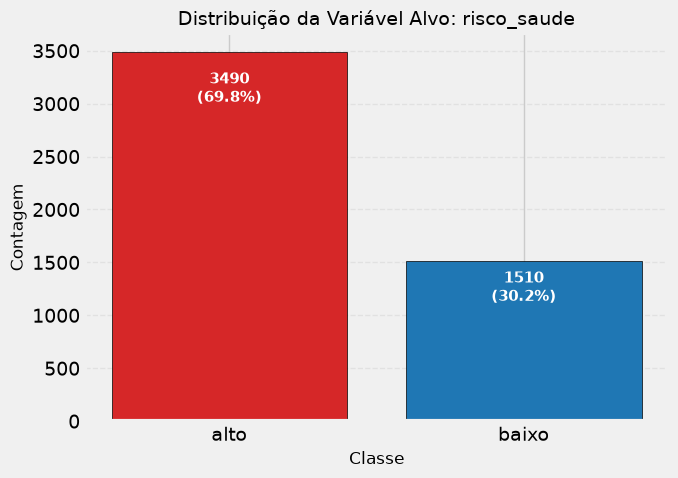

In [21]:
# ============================================================
# DISTRIBUIÇÃO DA VARIÁVEL ALVO (risco_saude)
# ============================================================
# Antes de qualquer análise mais profunda, é importante entender
# como a variável que queremos estudar (aqui, o risco de saúde)
# está distribuída: existem mais pessoas de risco baixo ou alto?
# Isso é chamado de "distribuição da variável alvo".

# .value_counts() conta quantas vezes cada valor único aparece na coluna
counts = df['risco_saude'].value_counts()

# Calculamos a porcentagem de cada classe em relação ao total
percent = (counts / counts.sum()) * 100

# Definimos uma cor para cada categoria, para deixar o gráfico
# mais fácil de interpretar (azul = risco baixo, vermelho = risco alto)
colors = {
    'baixo': '#1f77b4',   # azul
    'alto': '#d62728'     # vermelho
}

plt.figure(figsize=(7,5))

# Criamos um gráfico de barras: uma barra para cada categoria de risco_saude
bars = plt.bar(counts.index, counts.values,
               color=[colors[x] for x in counts.index],
               edgecolor='black')

# Configurações visuais do gráfico (título e nomes dos eixos)
plt.title("Distribuição da Variável Alvo: risco_saude", fontsize=14)
plt.xlabel("Classe", fontsize=12)
plt.ylabel("Contagem", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Escrevemos, dentro de cada barra, a contagem e a porcentagem
# correspondente, para facilitar a leitura do gráfico
for i, bar in enumerate(bars):
    cls = counts.index[i]
    value = counts.values[i]
    pct = percent.values[i]

    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() - (bar.get_height()*0.05),
             f"{value}\n({pct:.1f}%)",
             ha='center', va='top', color='white', fontsize=11, fontweight='bold')

plt.tight_layout()  # ajusta o layout para nada ficar cortado
plt.show()           # exibe o gráfico na tela


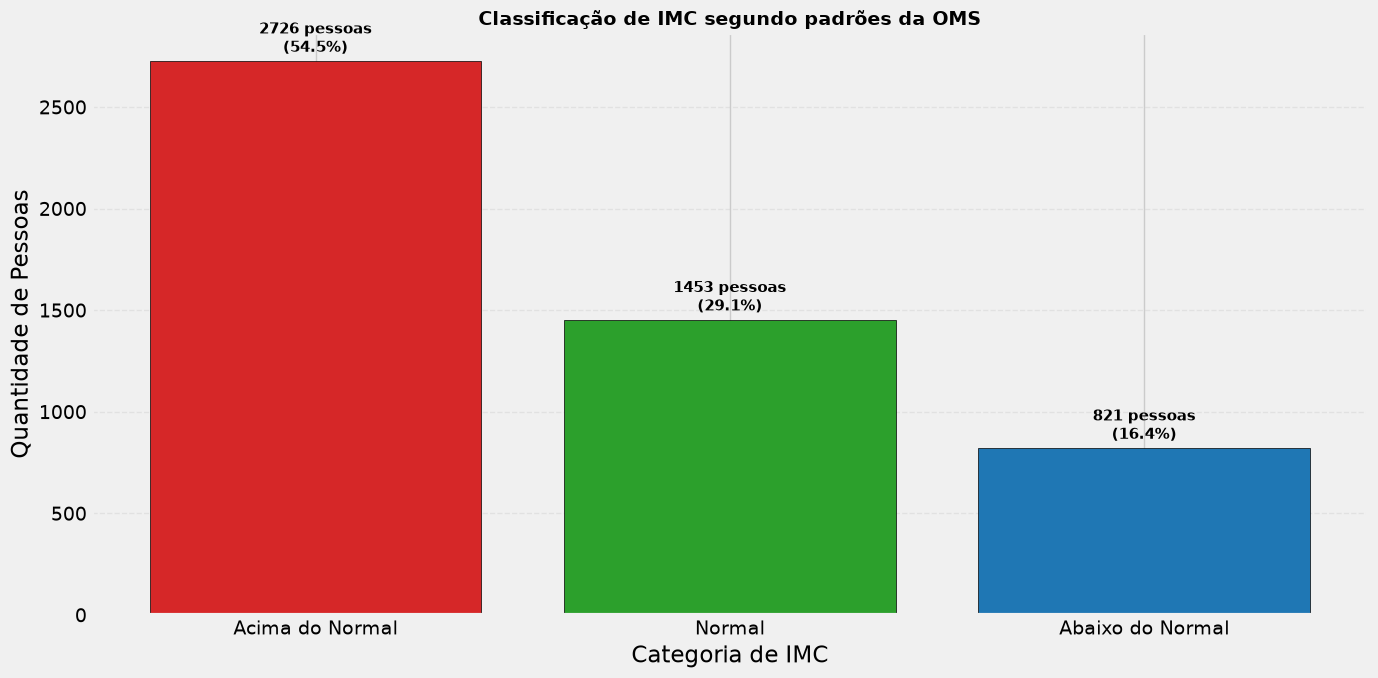

In [22]:
# ============================================================
# CLASSIFICAÇÃO DE IMC CONFORME A OMS
# ============================================================
# Vamos criar uma nova coluna categorizando o IMC (Índice de Massa
# Corporal) de cada pessoa, seguindo as faixas oficiais da OMS
# (Organização Mundial da Saúde).

# Criamos uma cópia do DataFrame original para não alterar o df principal
df_temp = df.copy()

# .apply() aplica uma função a cada valor da coluna 'imc'.
# Aqui usamos uma função lambda (uma função "de uma linha só") que
# recebe o valor do IMC (x) e devolve a categoria correspondente
df_temp['categoria_imc'] = df_temp['imc'].apply(
    lambda x: 'Abaixo do Normal' if x < 18.5 else
              'Normal' if 18.5 <= x <= 24.9 else
              'Acima do Normal'
)

# Contamos quantas pessoas caem em cada categoria de IMC
counts = df_temp['categoria_imc'].value_counts()

# Cor para cada categoria
colors = {
    'Abaixo do Normal': '#1f77b4',   # azul
    'Normal': '#2ca02c',            # verde
    'Acima do Normal': '#d62728'    # vermelho
}

plt.figure(figsize=(14,7))

bars = plt.bar(
    counts.index,
    counts.values,
    color=[colors[c] for c in counts.index],
    edgecolor='black'
)

# Título + eixos
plt.title("Classificação de IMC segundo padrões da OMS", fontsize=14, fontweight='bold')
plt.xlabel("Categoria de IMC")
plt.ylabel("Quantidade de Pessoas")
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Anotações com a quantidade e o percentual de pessoas em cada categoria
total = counts.sum()
for i, bar in enumerate(bars):
    value = counts.values[i]
    pct = (value / total) * 100
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        f"{value} pessoas\n({pct:.1f}%)",
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.show()


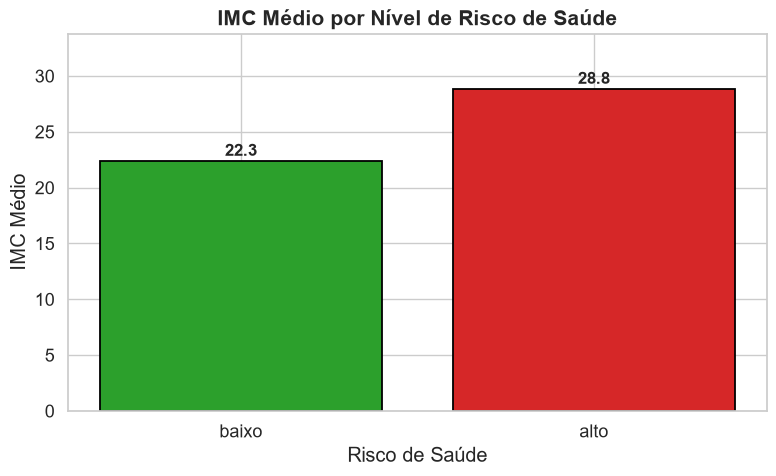

In [23]:
# ============================================================
# RISCO DE SAÚDE EM FUNÇÃO DO IMC MÉDIO
# ============================================================
# sns.set() define um estilo visual (grade branca) e aumenta um
# pouco o tamanho das fontes dos gráficos seaborn
sns.set(style="whitegrid", font_scale=1.2)

# .groupby() agrupa as linhas pelo valor da coluna 'risco_saude'
# e .mean() calcula a média do IMC dentro de cada grupo.
# .reset_index() transforma o resultado de volta em um DataFrame comum
imc_medio = df.groupby('risco_saude')['imc'].mean().reset_index()

# Definimos a ordem em que as categorias vão aparecer no gráfico
order = ['baixo', 'alto']
imc_medio = imc_medio.set_index('risco_saude').loc[order].reset_index()

# Cor de cada barra
colors = {
    'baixo': '#2ca02c',   # verde = saudável
    'alto': '#d62728'     # vermelho = risco alto
}

plt.figure(figsize=(8,5))

bars = plt.bar(
    imc_medio['risco_saude'],
    imc_medio['imc'],
    color=[colors[x] for x in imc_medio['risco_saude']],
    edgecolor="black",
    linewidth=1.3
)

# Escreve o valor do IMC médio em cima de cada barra
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.1f}",
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

# Configurações do gráfico
plt.title("IMC Médio por Nível de Risco de Saúde", fontsize=15, fontweight='bold')
plt.xlabel("Risco de Saúde")
plt.ylabel("IMC Médio")
plt.ylim(0, imc_medio['imc'].max() + 5)

plt.tight_layout()
plt.show()


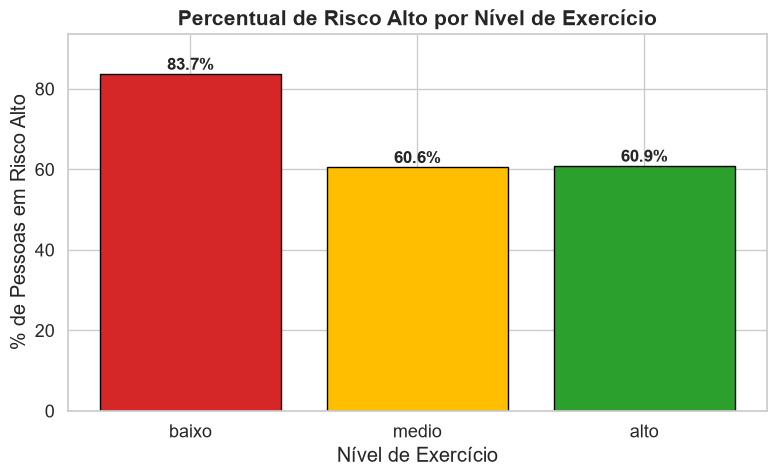

In [25]:
# ============================================================
# RISCO DE SAÚDE EM FUNÇÃO DO NÍVEL DE EXERCÍCIO
# ============================================================
# Filtramos o DataFrame para manter apenas as linhas em que o
# risco de saúde é 'baixo' ou 'alto' (removendo outras categorias,
# caso existam)
df_ex = df[df['risco_saude'].isin(['baixo', 'alto'])]

# Para cada nível de exercício, calculamos qual a porcentagem de
# pessoas que têm risco 'alto'.
# A expressão (x == 'alto').mean() funciona porque True vale 1 e
# False vale 0: a média dos True/False é a proporção de 'alto'.
exercicio_pct = (
    df_ex.groupby('exercicio')['risco_saude']
         .apply(lambda x: (x == 'alto').mean() * 100)
         .reindex(['baixo', 'medio', 'alto'])  # garante a ordem das barras
)

sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(8,5))
bars = plt.bar(
    exercicio_pct.index,
    exercicio_pct.values,
    color=['#d62728', '#ffbf00', '#2ca02c'],  # vermelho, amarelo, verde
    edgecolor="black"
)

# Adiciona o valor percentual em cima de cada barra
for i, bar in enumerate(bars):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{bar.get_height():.1f}%",
        ha='center', fontsize=12, fontweight='bold'
    )

plt.title("Percentual de Risco Alto por Nível de Exercício", fontsize=15, fontweight='bold')
plt.xlabel("Nível de Exercício")
plt.ylabel("% de Pessoas em Risco Alto")
plt.ylim(0, exercicio_pct.max() + 10)
plt.tight_layout()
plt.show()


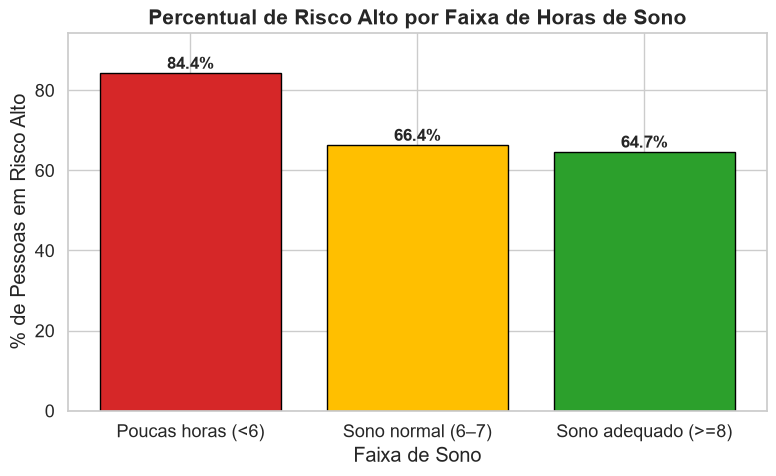

In [26]:
# ============================================================
# RISCO DE SAÚDE EM FUNÇÃO DAS HORAS DE SONO
# ============================================================
# Filtramos apenas as classes 'baixo' e 'alto'
df_sono = df[df['risco_saude'].isin(['baixo', 'alto'])]

# pd.cut() transforma uma coluna numérica contínua (horas de sono)
# em faixas categóricas (bins), o que deixa a análise mais didática
df_sono['categoria_sono'] = pd.cut(
    df_sono['sono'],
    bins=[0, 5.9, 6.9, 10],
    labels=['Poucas horas (<6)', 'Sono normal (6–7)', 'Sono adequado (>=8)']
)

# Calculamos, para cada faixa de sono, a porcentagem de pessoas
# com risco alto ('alto')
sono_pct = (
    df_sono.groupby('categoria_sono')['risco_saude']
           .apply(lambda x: (x == 'alto').mean() * 100)
)

# Visualização
sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(8,5))

bars = plt.bar(
    sono_pct.index,
    sono_pct.values,
    color=['#d62728', '#ffbf00', '#2ca02c'],   # vermelho, amarelo, verde
    edgecolor='black'
)

# Adiciona o valor percentual em cima de cada barra
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{bar.get_height():.1f}%",
        ha='center', fontsize=12, fontweight='bold'
    )

plt.title("Percentual de Risco Alto por Faixa de Horas de Sono", fontsize=15, fontweight='bold')
plt.ylabel("% de Pessoas em Risco Alto")
plt.xlabel("Faixa de Sono")
plt.ylim(0, sono_pct.max() + 10)
plt.tight_layout()
plt.show()


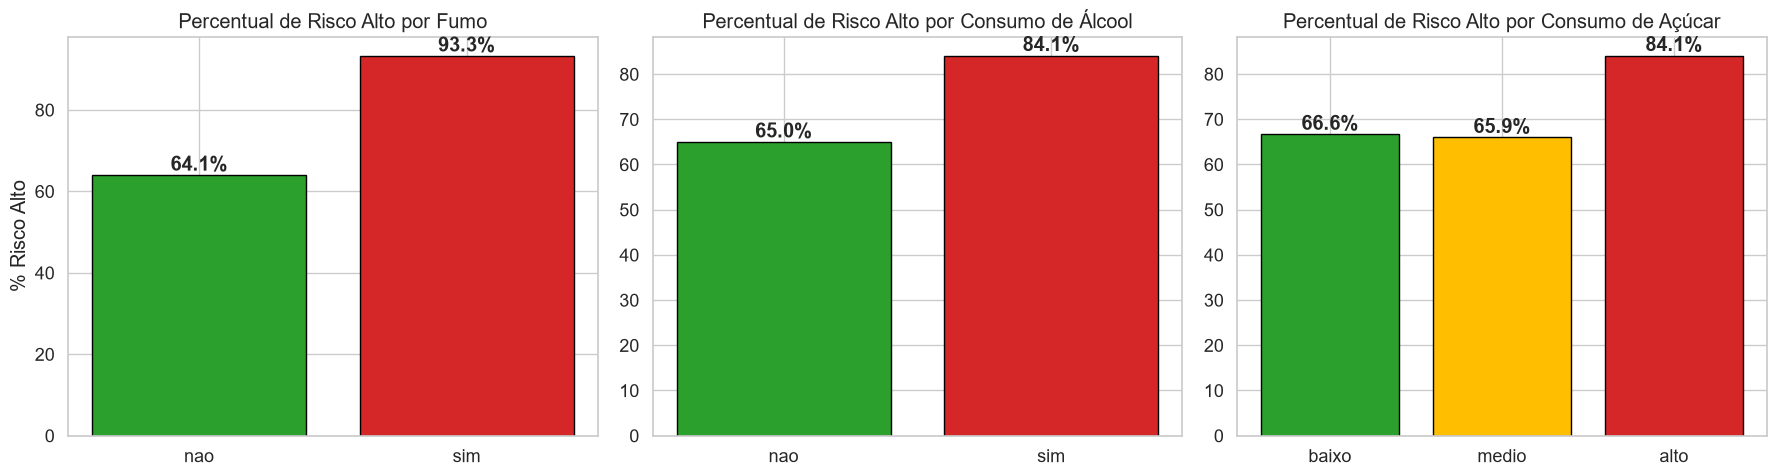

In [29]:
# ============================================================
# RISCO DE SAÚDE EM FUNÇÃO DE HÁBITOS (FUMO, ÁLCOOL E AÇÚCAR)
# ============================================================
sns.set(style="whitegrid", font_scale=1.2)

# Mantemos apenas as classes 'baixo' e 'alto'
df_hab = df[df['risco_saude'].isin(['baixo', 'alto'])]

# plt.subplots(1, 3, ...) cria uma figura com 3 gráficos lado a lado,
# um para cada hábito analisado
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# --- FUMANTE ---
# Percentual de risco alto entre fumantes e não fumantes
fumante_pct = (
    df_hab.groupby('fumante')['risco_saude']
          .apply(lambda x: (x=='alto').mean()*100)
)

axes[0].bar(fumante_pct.index, fumante_pct.values,
            color=['#2ca02c', '#d62728'], edgecolor='black')

for i, v in enumerate(fumante_pct.values):
    axes[0].text(i, v+1, f"{v:.1f}%", ha='center', fontweight='bold')

axes[0].set_title("Percentual de Risco Alto por Fumo")
axes[0].set_ylabel("% Risco Alto")


# --- ÁLCOOL ---
# Percentual de risco alto entre quem consome e quem não consome álcool
alcool_pct = (
    df_hab.groupby('alcool')['risco_saude']
          .apply(lambda x: (x=='alto').mean()*100)
)

axes[1].bar(alcool_pct.index, alcool_pct.values,
            color=['#2ca02c', '#d62728'], edgecolor='black')

for i, v in enumerate(alcool_pct.values):
    axes[1].text(i, v+1, f"{v:.1f}%", ha='center', fontweight='bold')

axes[1].set_title("Percentual de Risco Alto por Consumo de Álcool")


# --- AÇÚCAR ---
# Percentual de risco alto por nível de consumo de açúcar (baixo/medio/alto)
acucar_pct = (
    df_hab.groupby('consumo_acucar')['risco_saude']
          .apply(lambda x: (x=='alto').mean()*100)
          .loc[['baixo','medio','alto']]  # ordem coerente
)

axes[2].bar(acucar_pct.index, acucar_pct.values,
            color=['#2ca02c', '#ffbf00', '#d62728'], edgecolor='black')

for i, v in enumerate(acucar_pct.values):
    axes[2].text(i, v+1, f"{v:.1f}%", ha='center', fontweight='bold')

axes[2].set_title("Percentual de Risco Alto por Consumo de Açúcar")
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# COMBINAÇÃO DE MAUS HÁBITOS: FUMAR E BEBER AO MESMO TEMPO
# ============================================================
# Criamos uma condição booleana (True/False) que identifica as
# pessoas que fumam E também consomem álcool
cond = (
    (df['fumante'] == 'sim') &
    (df['alcool'] == 'sim')
)

# Usamos essa condição para filtrar apenas essas pessoas
df_ruim = df[cond]

# Calculamos a porcentagem dessas pessoas que têm risco alto
prob_alto = (df_ruim['risco_saude'] == 'alto').mean() * 100

# Quantidade total de pessoas nesse grupo
total_pessoas = len(df_ruim)

prob_alto, total_pessoas


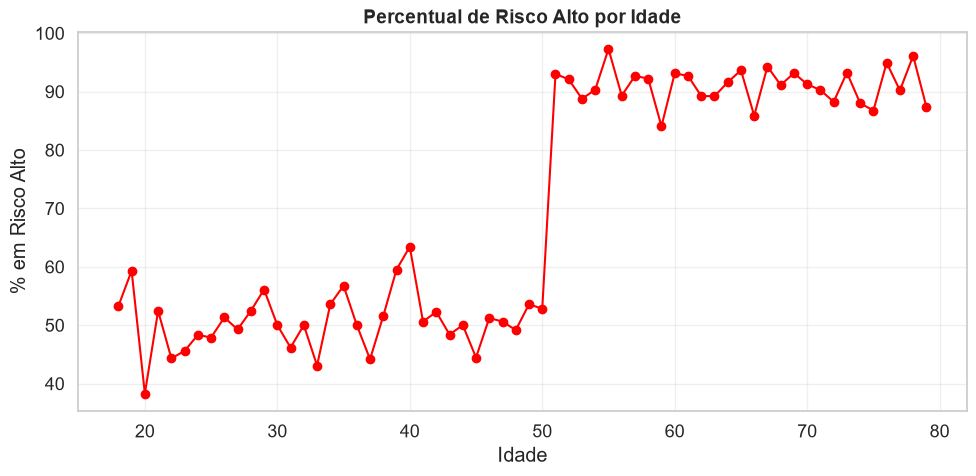

In [30]:
# ============================================================
# RISCO DE SAÚDE EM FUNÇÃO DA IDADE (POR IDADE EXATA)
# ============================================================
# Filtramos apenas 'baixo' e 'alto'
df_idade = df[df['risco_saude'].isin(['baixo', 'alto'])]

# Para cada idade exata, calculamos o percentual de pessoas com risco alto
idade_pct = (
    df_idade.groupby('idade')['risco_saude']
            .apply(lambda x: (x == 'alto').mean() * 100)
)

plt.figure(figsize=(10,5))
# Aqui usamos um gráfico de linha (plt.plot), pois estamos olhando
# para uma tendência ao longo de uma variável contínua (a idade)
plt.plot(idade_pct.index, idade_pct.values, marker='o', color='red')
plt.title("Percentual de Risco Alto por Idade", fontsize=14, fontweight="bold")
plt.xlabel("Idade")
plt.ylabel("% em Risco Alto")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


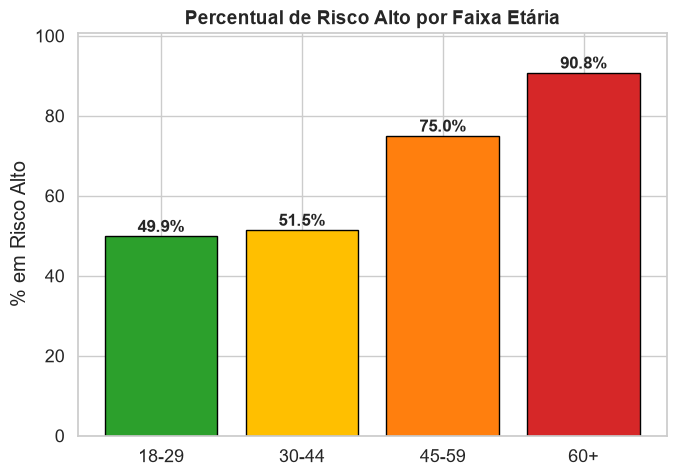

In [31]:
# ============================================================
# RISCO DE SAÚDE POR FAIXA ETÁRIA (IDADES AGRUPADAS)
# ============================================================
# Criamos uma cópia do DataFrame para não alterar o original
df_temp = df.copy()

# pd.cut() agrupa as idades em faixas (bins), facilitando a leitura
df_temp['faixa_etaria'] = pd.cut(
    df_temp['idade'],
    bins=[17, 29, 44, 59, 90],
    labels=['18-29', '30-44', '45-59', '60+']
)

# Percentual de risco alto dentro de cada faixa etária
faixa_pct = (
    df_temp[df_temp['risco_saude'].isin(['baixo','alto'])]
      .groupby('faixa_etaria')['risco_saude']
      .apply(lambda x: (x=='alto').mean()*100)
)

plt.figure(figsize=(7,5))
bars = plt.bar(
    faixa_pct.index,
    faixa_pct.values,
    color=['#2ca02c','#ffbf00','#ff7f0e','#d62728'],
    edgecolor='black'
)

# Texto com o percentual em cima de cada barra
for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+1,
        f"{bar.get_height():.1f}%",
        ha='center', fontsize=12, fontweight='bold'
    )

plt.title("Percentual de Risco Alto por Faixa Etária", fontsize=14, fontweight="bold")
plt.ylabel("% em Risco Alto")
plt.ylim(0, max(faixa_pct.values)+10)
plt.tight_layout()
plt.show()


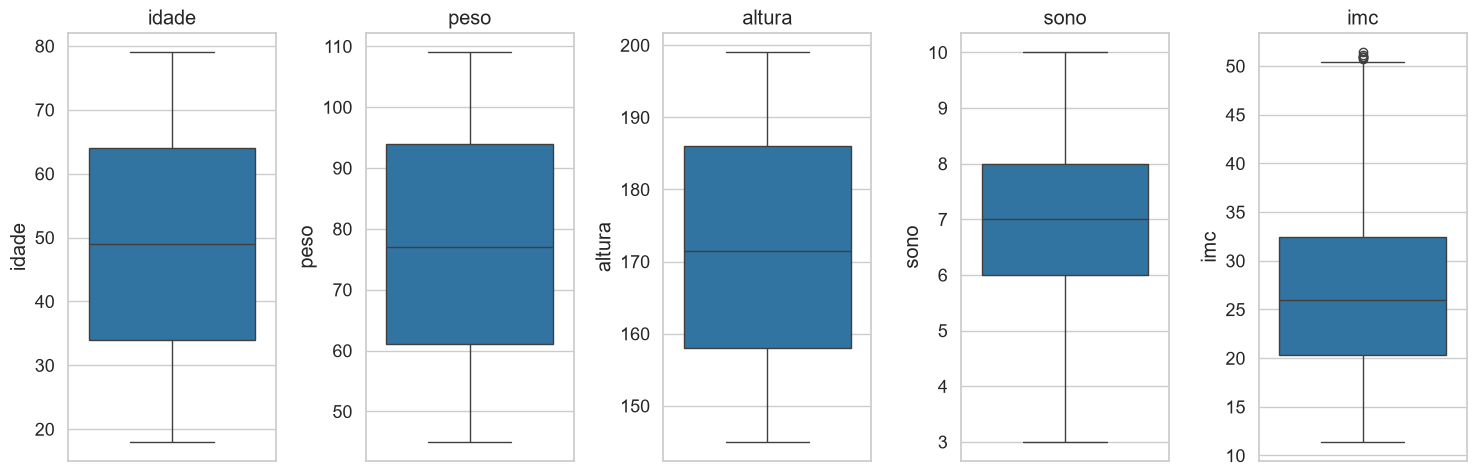

,Outliers
idade,0
peso,0
altura,0
sono,0
imc,6


In [32]:
# ============================================================
# IDENTIFICANDO OUTLIERS (VALORES ATÍPICOS) NAS VARIÁVEIS NUMÉRICAS
# ============================================================
sns.set(style="whitegrid", font_scale=1.2)

# select_dtypes() seleciona automaticamente apenas as colunas de
# um determinado tipo — aqui, números inteiros e decimais
# (no nosso caso: idade, peso, altura, sono, imc)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Um boxplot é um gráfico que mostra a distribuição de uma variável
# numérica e destaca visualmente os possíveis outliers (pontos fora
# da caixa)
plt.figure(figsize=(15, 5))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, len(num_cols), i)  # cria um "sub-gráfico" na posição i
    sns.boxplot(y=df[col], color="#1f77b4")
    plt.title(col)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Cálculo de outliers pelo método do IQR (Intervalo Interquartil)
# ------------------------------------------------------------------
# Q1 = quartil de 25%, Q3 = quartil de 75%
# IQR = Q3 - Q1 (mede a "dispersão" central dos dados)
# Um valor é considerado outlier se estiver abaixo de (Q1 - 1.5*IQR)
# ou acima de (Q3 + 1.5*IQR)
outliers = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers[col] = df[(df[col] < lower) | (df[col] > upper)].shape[0]

# Monta uma tabela final com a quantidade de outliers por coluna
pd.DataFrame.from_dict(outliers, orient='index', columns=['Outliers'])


In [33]:
# ============================================================
# INSPECIONANDO OS OUTLIERS DE IMC
# ============================================================
# Reaproveitamos os limites 'lower' e 'upper' calculados na célula
# anterior (para a coluna 'imc', que foi a última avaliada no loop)
# para filtrar e observar quais linhas da tabela são consideradas
# outliers de IMC
imc_outliers = df[(df['imc'] < lower) | (df['imc'] > upper)]

imc_outliers


,idade,peso,altura,exercicio,sono,consumo_acucar,fumante,alcool,casado,profissao,imc,risco_saude
544,40,107,145,alto,7.3,alto,nao,nao,nao,trabalhador_de_escritorio,50.9,alto
2814,64,107,145,baixo,8.2,medio,nao,nao,nao,engenheiro,50.9,alto
3153,30,109,146,medio,6.5,medio,nao,nao,sim,estudante,51.1,baixo
3964,78,107,145,medio,7.6,medio,nao,sim,sim,medico,50.9,alto
4708,40,108,145,baixo,7.5,alto,nao,nao,sim,medico,51.4,alto
4912,18,108,146,nenhum,8.6,medio,nao,nao,sim,engenheiro,50.7,alto


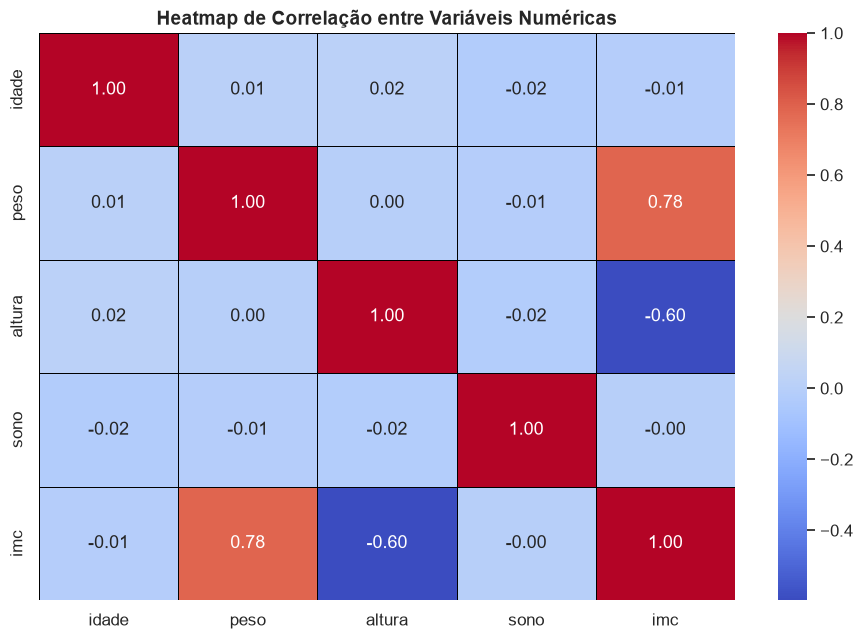

In [34]:
# ============================================================
# CORRELAÇÃO ENTRE VARIÁVEIS NUMÉRICAS
# ============================================================
sns.set(style="whitegrid", font_scale=1.1)

# Seleciona apenas as colunas numéricas
num_cols = df.select_dtypes(include=['int64', 'float64'])

# .corr() calcula a correlação de Pearson entre cada par de colunas
# numéricas. O resultado varia de -1 (correlação negativa perfeita)
# a +1 (correlação positiva perfeita), passando por 0 (sem correlação)
corr = num_cols.corr()

plt.figure(figsize=(10,7))
# Um heatmap (mapa de calor) é uma ótima forma de visualizar uma
# matriz de correlação: cores mais quentes/frias indicam correlações
# mais fortes em cada direção
sns.heatmap(
    corr,
    annot=True,        # escreve o valor numérico dentro de cada célula
    cmap='coolwarm',    # paleta de cores (azul a vermelho)
    linewidths=0.5,
    linecolor='black',
    fmt=".2f"           # formata os números com 2 casas decimais
)

plt.title("Heatmap de Correlação entre Variáveis Numéricas", fontsize=14, fontweight='bold')
plt.show()


In [ ]:
# ============================================================
# CORRELAÇÃO PONTO-BISSERIAL COM A VARIÁVEL ALVO
# ============================================================
# A correlação de Pearson tradicional exige duas variáveis numéricas
# contínuas. Como nossa variável alvo (risco_saude) é categórica
# (baixo/alto), usamos a correlação ponto-bisserial, que mede a
# relação entre uma variável numérica contínua e uma variável
# binária (0/1).
from scipy.stats import pointbiserialr

# Cria uma variável binária a partir de 'risco_saude'
df_temp = df.copy()
df_temp['risco_binario'] = df_temp['risco_saude'].map({'baixo':0, 'alto':1})

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

corr_pb = {}

# Para cada coluna numérica, calculamos a correlação com o risco binário
for col in num_cols:
    if col != 'risco_binario':
        corr, p = pointbiserialr(df_temp['risco_binario'], df_temp[col])
        corr_pb[col] = corr

# Organiza o resultado em um DataFrame para plotar como heatmap
corr_df = pd.DataFrame.from_dict(corr_pb, orient='index', columns=['correlacao'])

plt.figure(figsize=(6,8))
sns.heatmap(
    corr_df,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='black',
    fmt=".2f"
)

plt.title("Correlação (Point-Biserial) com a Variável Alvo", fontsize=14, fontweight='bold')
plt.show()


In [ ]:
# ============================================================
# ASSOCIAÇÃO ENTRE HÁBITOS (CATEGÓRICOS) E O RISCO DE SAÚDE
# ============================================================
# Para medir a associação entre duas variáveis CATEGÓRICAS (por
# exemplo, 'fumante' e 'risco_saude'), usamos o coeficiente de
# Cramér's V, que é baseado no teste qui-quadrado (chi2).
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    # Cria uma tabela de contingência (cruzamento) entre x e y
    confusion = pd.crosstab(x, y)
    # Calcula a estatística qui-quadrado dessa tabela
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()          # número total de observações
    r, k = confusion.shape             # número de linhas e colunas da tabela
    # Fórmula do Cramér's V (varia de 0 = nenhuma associação, a 1 = associação total)
    return np.sqrt(chi2 / (n * (min(r,k) - 1)))

# Colunas categóricas que vamos comparar com o risco de saúde
cat_cols = ['exercicio', 'consumo_acucar', 'fumante', 'alcool', 'casado', 'profissao']

results_cv = {}

for col in cat_cols:
    results_cv[col] = cramers_v(df[col], df['risco_saude'])

# Transforma o dicionário de resultados em um DataFrame
cv_df = pd.DataFrame.from_dict(results_cv, orient='index', columns=['associacao'])

plt.figure(figsize=(6,8))
sns.heatmap(
    cv_df,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='black',
    fmt=".2f"
)

plt.title("Associação (Cramér’s V) entre Hábitos e o Risco de Saúde", fontsize=14, fontweight='bold')
plt.show()


## Conclusão

Com essas análises, exploramos como diferentes hábitos e características (IMC, exercício, sono, tabagismo, consumo de álcool e açúcar, idade, etc.) se relacionam com o risco de saúde das pessoas na base de dados — tudo usando nomes de colunas e valores em português.

Todo o conteúdo relacionado à criação de um **modelo preditivo de Machine Learning** (separação em treino/validação/teste, codificação das variáveis para o modelo, treinamento de uma árvore de decisão e avaliação de métricas como acurácia, precisão e recall) foi removido deste notebook, mantendo o foco apenas na etapa de **Análise Exploratória de Dados**.


# Desafio 1: Ingestão e Reconhecimento dos Dados

Pergunta: Quantas linhas e colunas existem na base de dados? Quais são os nomes das colunas e os tipos de dados armazenados?

Dica: Utilize as funções do Pandas para carregar o arquivo CSV e inspecionar a estrutura inicial.

Comandos úteis: pd.read_csv(), df.shape, df.info(), df.head().

In [ ]:
df = pd.read_csv("C:\Pedro Augusto Taroco Santos\CursoPython\py\Analise_Dados\ArquivoExcel\Lifestyle_and_Health_Risk_Prediction_Dataset_PT.csv")
print(df.shape) # -> Mostra qtd de colunas e linhas

print("="*30)

df.info() # -> Descreve os nomes das colunas e os tipos de dados

(5000, 12)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   idade           5000 non-null   int64  
 1   peso            5000 non-null   int64  
 2   altura          5000 non-null   int64  
 3   exercicio       5000 non-null   str    
 4   sono            5000 non-null   float64
 5   consumo_acucar  5000 non-null   str    
 6   fumante         5000 non-null   str    
 7   alcool          5000 non-null   str    
 8   casado          5000 non-null   str    
 9   profissao       5000 non-null   str    
 10  imc             5000 non-null   float64
 11  risco_saude     5000 non-null   str    
dtypes: float64(2), int64(3), str(7)
memory usage: 632.9 KB


# Desafio 2: Resumo Estatístico das Variáveis Numéricas
Pergunta: Qual é a idade média, o IMC médio e a quantidade média de horas de sono das pessoas pesquisadas? Qual é o peso máximo registrado?

Dica: Calcule estatísticas descritivas gerais com uma única função ou selecione colunas específicas.

Comandos úteis: df.describe() ou .mean(), .max().

In [63]:
df.describe()
medias = {
    "idade_media": df['idade'].mean(),
    "imc_medio": df['imc'].mean(),
    "sono_medio": df['sono'].mean()
    }

print(f"A idade média é: {medias["idade_media"]}")
print(f"O imc médio é: {medias["imc_medio"]}")
print(f"O tempo de sono médio é: {medias["sono_medio"]}")

maior_peso = df["peso"].max()
print("Maior Peso: ",maior_peso,"KG")


A idade média é: 48.8056
O imc médio é: 26.843880000000006
O tempo de sono médio é: 6.99706
Maior Peso:  109 KG


# Desafio 3: Análise de Frequências (Hábitos e Risco)
Pergunta:Quantas pessoas no estudo são fumantes e quantas não são?Qual é a porcentagem (%) de pessoas classificadas com risco de saúde alto vs baixo?

Dica: Utilize a contagem de valores das colunas categóricas e ative a normalização para obter percentuais.

Comandos úteis: df['fumante'].value_counts() e df['risco_saude'].value_counts(normalize=True) * 100.

In [55]:
qtd_fumantes = (df["fumante"] == "sim").sum()
porcentagem = (df["fumante"] == "sim").value_counts(normalize= True) * 100
porcentagem = porcentagem.loc[True]

print(f"A porcentagem de fumantes é: {porcentagem:.2f}% - {qtd_fumantes} pessoas")


A porcentagem de fumantes é: 19.54% - 977 pessoas


# Desafio 4: Análise Bivariada (Cruzando Dados)
Pergunta: Pessoas com risco de saúde alto têm, em média, maior idade e IMC mais elevado do que pessoas com risco baixo?

Dica: Agrupe a base de dados pela coluna risco_saude e calcule a média das variáveis numéricas (idade, imc e sono).

Comandos úteis: df.groupby('risco_saude')[['idade', 'imc', 'sono']].mean().